# IMPORT LIBRARY

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
import pillow_heif
import seaborn as sns
import pandas as pd

# LOAD DATASET

In [2]:
day = r"C:\MATTHEW\DATA SEKUNDER\Day"
night = r"C:\MATTHEW\DATA SEKUNDER\Night"

day_Resized = r"C:\MATTHEW\DATA SEKUNDER\Resized 256 x 256\Day"
night_Resized = r"C:\MATTHEW\DATA SEKUNDER\Resized 256 x 256\Night"

os.makedirs(day_Resized, exist_ok=True)
os.makedirs(night_Resized, exist_ok=True)

# Data Preprocessing

## Show Image

In [3]:
def show_image(input_dir, title=""):
    file_list = [f for f in os.listdir(input_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:40]
    plt.figure(figsize=(20, 4))
    for i, file_name in enumerate(file_list):
        img_path = os.path.join(input_dir, file_name)
        with Image.open(img_path) as img:
            plt.subplot(4, 10, i + 1)
            plt.imshow(img)
            plt.axis('off')
    plt.suptitle(title)
    plt.show()

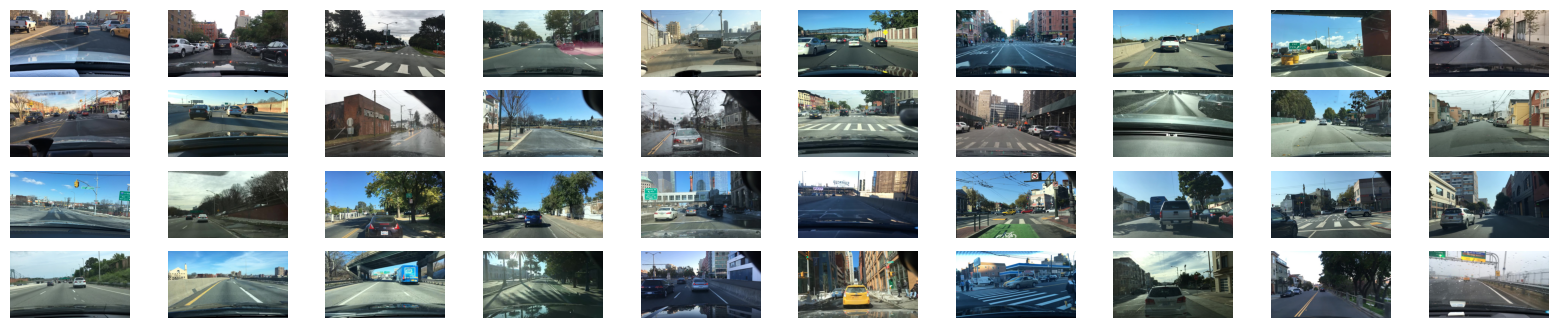

In [4]:
show_image(day)

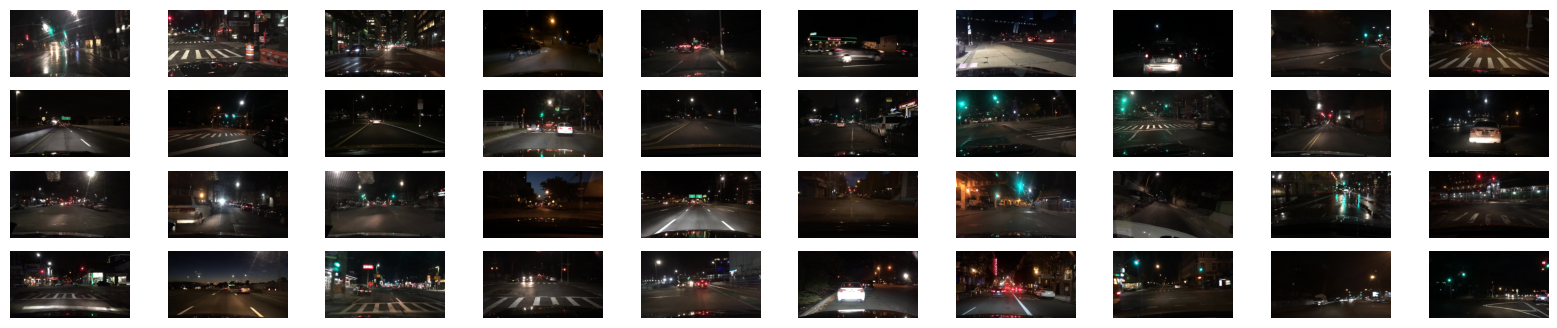

In [5]:
show_image(night)

## Image Size

In [7]:
day_sample = os.path.join(day, os.listdir(day)[7])
night_sample = os.path.join(night, os.listdir(night)[2])

def visualize_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    height, width = img_np.shape[:2]
    aspect_ratio = width / height
    fig_width = 8 * aspect_ratio
    fig_height = 8

    plt.figure(figsize=(fig_width, fig_height))
    plt.subplot(1, 1, 1)
    plt.imshow(img_np)
    plt.title(f"{width} x {height} x 3 image")
    plt.xlabel("Width (px)")
    plt.ylabel("Height (px)")

    plt.xticks(np.linspace(0, width, num=5, dtype=int))
    plt.yticks(np.linspace(0, height, num=5, dtype=int))
    plt.grid(True, linestyle="--", linewidth=0.5, color="white", alpha=0.7)

    plt.tight_layout()
    plt.show()

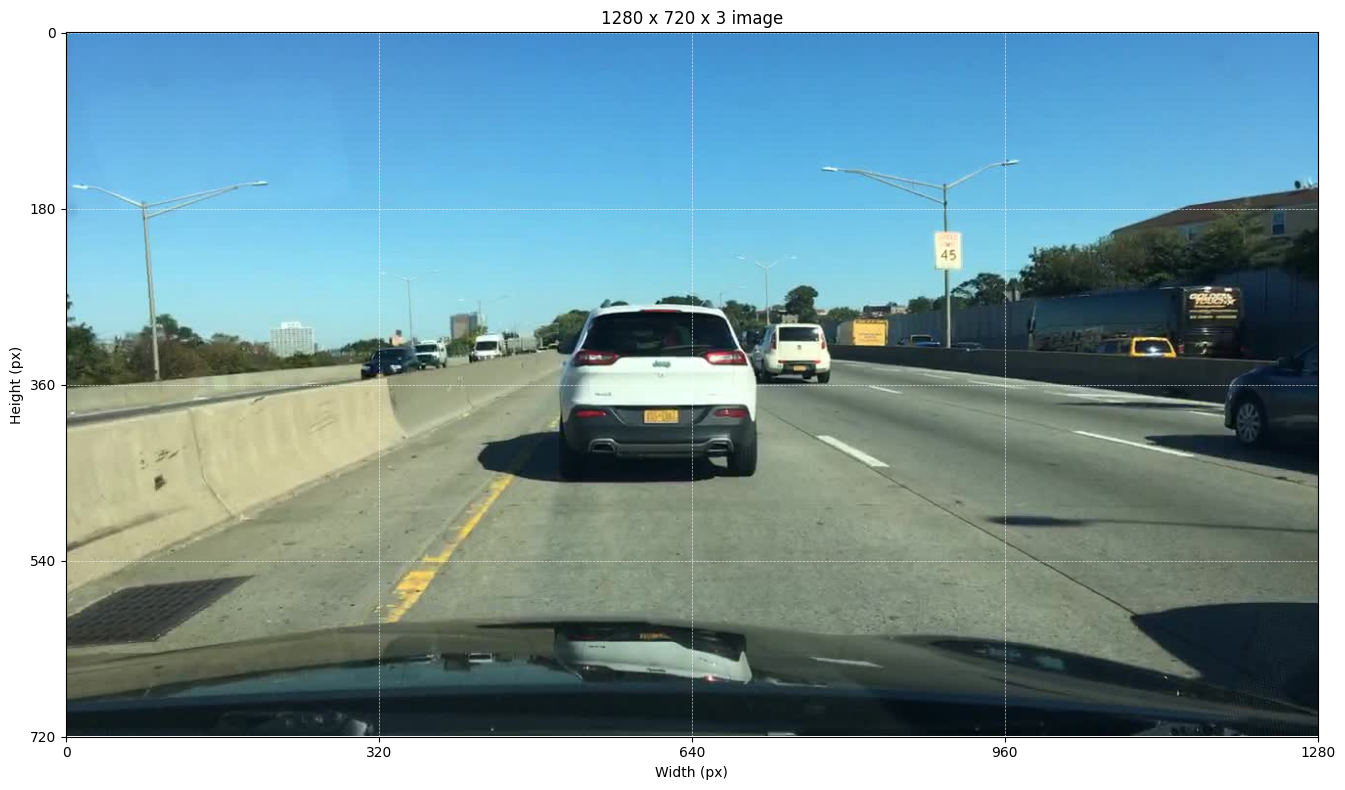

In [8]:
visualize_image(day_sample)

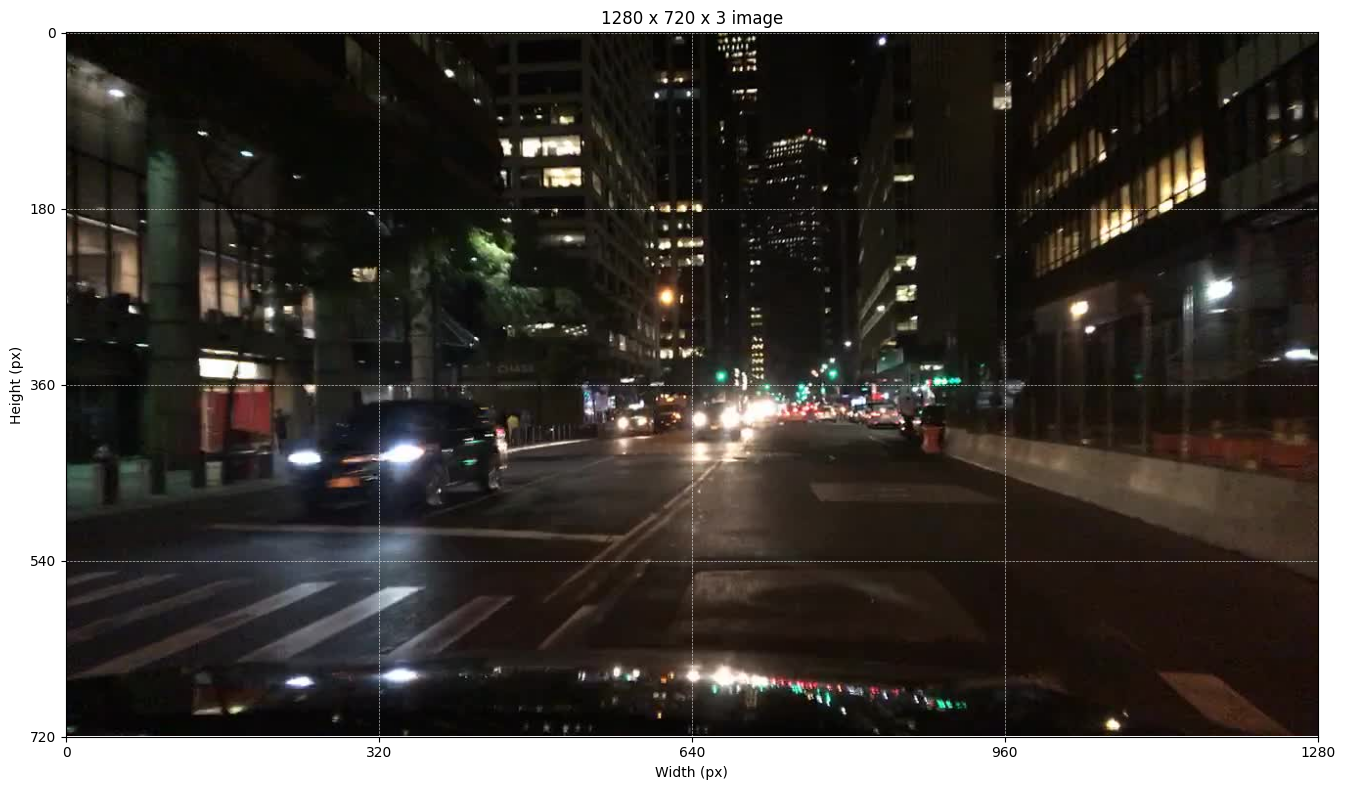

In [9]:
visualize_image(night_sample)

## Image Resize

In [ ]:
def resize_images(input_dir, output_dir, size=(256, 256)):
    for f in os.listdir(input_dir):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(input_dir, f)
            try:
                img = Image.open(path).convert("RGB")
                img = img.resize(size)
                img.save(os.path.join(output_dir, f))
            except Exception as e:
                print(f"Gagal resize {f}: {e}")

resize_images(day, day_Resized)
resize_images(night, night_Resized)

In [13]:
def show_images(input_dir, title=""):
    file_list = [f for f in os.listdir(input_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:20]
    plt.figure(figsize=(20, 5))
    for i, file_name in enumerate(file_list):
        img_path = os.path.join(input_dir, file_name)
        with Image.open(img_path) as img:
            plt.subplot(2, 10, i + 1)
            plt.imshow(img)
            plt.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

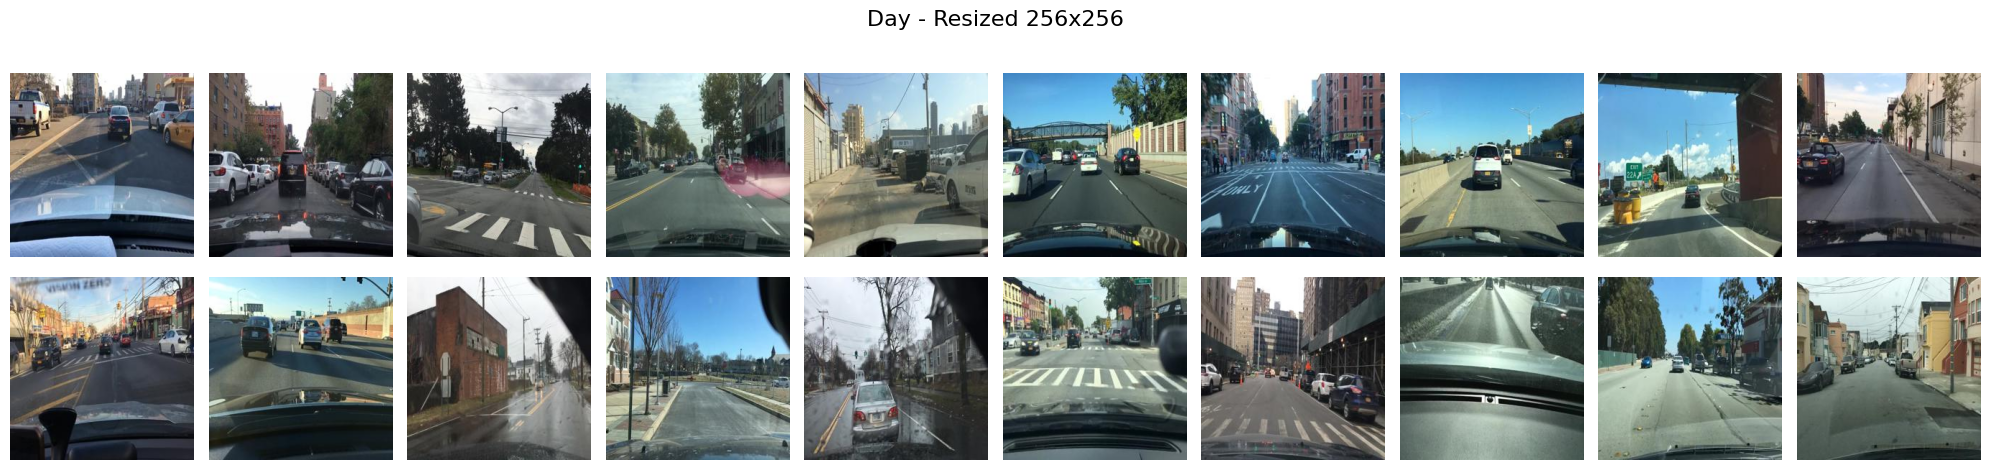

In [14]:
show_images(day_Resized, title="Day - Resized 256x256")

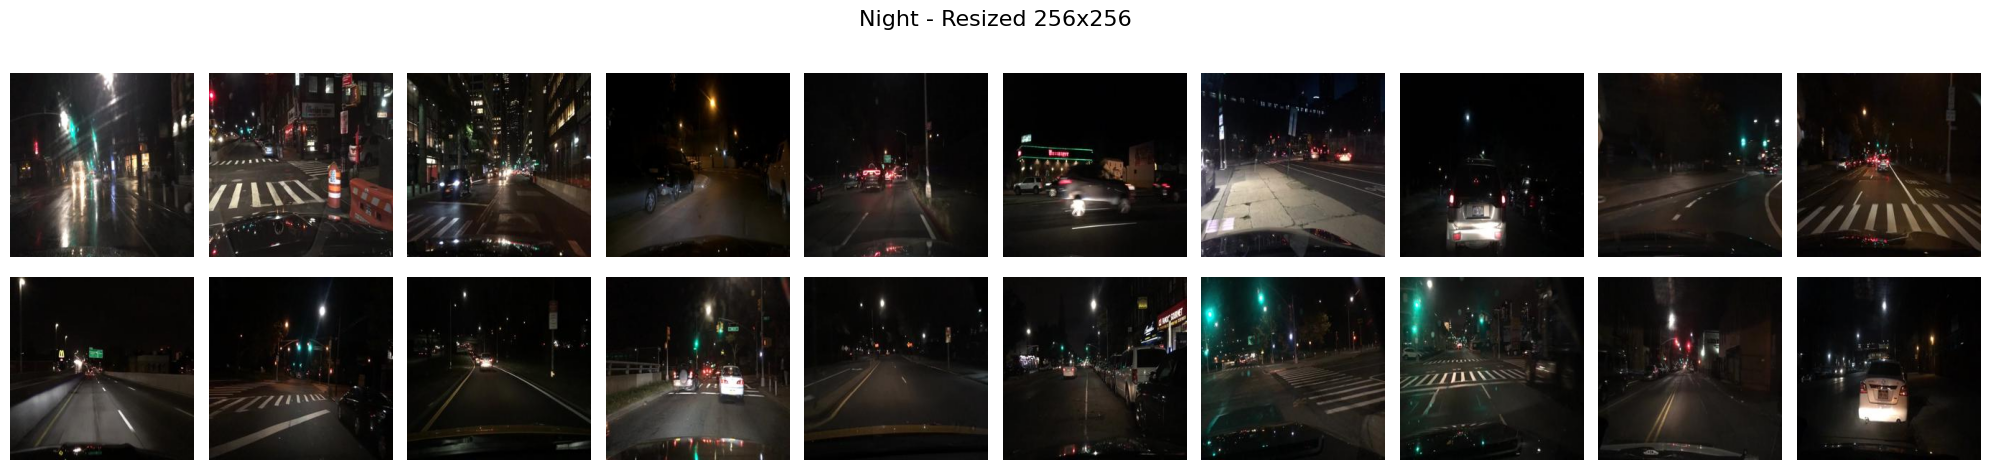

In [15]:
show_images(night_Resized, title="Night - Resized 256x256")

## Average image size

In [16]:
day_dir = day_Resized
night_dir = night_Resized

day_files = [f for f in os.listdir(day_dir) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
night_files = [f for f in os.listdir(night_dir) if f.lower().endswith(('jpg', 'jpeg', 'png'))]

print(f"Total Day images   : {len(day_files)}")
print(f"Total Night images : {len(night_files)}")

sizes = []
for path in [day_dir, night_dir]:
    for f in os.listdir(path)[:50]:
        with Image.open(os.path.join(path, f)) as img:
            sizes.append(img.size)

sizes_df = pd.DataFrame(sizes, columns=["width", "height"])
print("\nAverage image size :")
print(sizes_df.describe())

Total Day images   : 9000
Total Night images : 6000

Average image size :
       width  height
count  100.0   100.0
mean   256.0   256.0
std      0.0     0.0
min    256.0   256.0
25%    256.0   256.0
50%    256.0   256.0
75%    256.0   256.0
max    256.0   256.0


# Exploratory Data Analysis (EDA)

## Image Size

In [17]:
day_sample_Resized = os.path.join(day_Resized, os.listdir(day_Resized)[7])
night_sample_Resized = os.path.join(night_Resized, os.listdir(night_Resized)[2])

def visualize_image_with_rgb(image_path):
    img = Image.open(image_path).convert("RGB").resize((256, 256))
    img_np = np.array(img)

    plt.figure(figsize=(10, 6))
    plt.subplot(2, 2, 1)
    plt.imshow(img_np)
    plt.title("256 x 256 x 3 image")
    plt.xlabel("Width (px)")
    plt.ylabel("Height (px)")
    plt.xticks(np.arange(0, 257, 64))
    plt.yticks(np.arange(0, 257, 64))
    plt.grid(True, linestyle="--", linewidth=0.5, color="white", alpha=0.7)
    plt.tight_layout()
    plt.show()

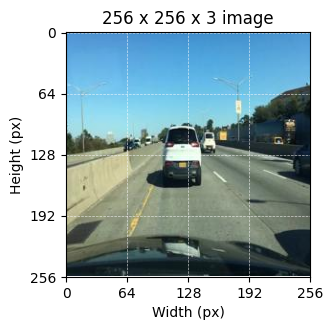

In [18]:
visualize_image_with_rgb(day_sample_Resized)

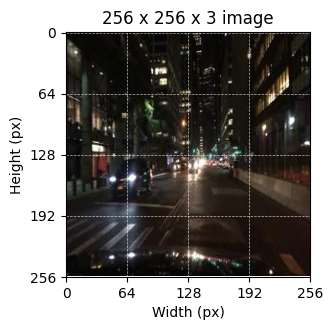

In [19]:
visualize_image_with_rgb(night_sample_Resized)

## Number of Datasets

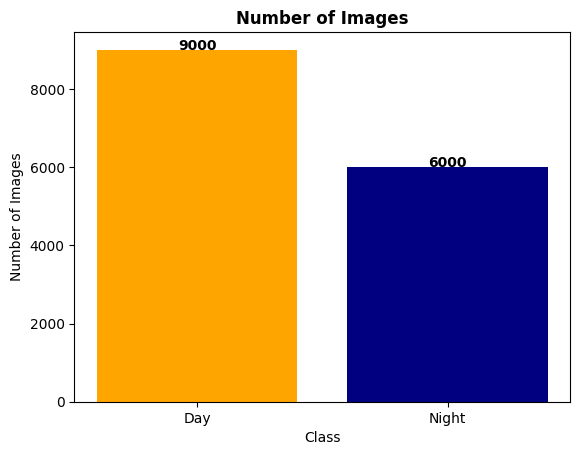

In [20]:
num_day = len([f for f in os.listdir(day_Resized) if f.lower().endswith(('jpg', 'jpeg', 'png'))])
num_night = len([f for f in os.listdir(night_Resized) if f.lower().endswith(('jpg', 'jpeg', 'png'))])

labels = ["Day", "Night"]
values = [num_day, num_night]
colors = ["orange", "navy"]

plt.bar(labels, values, color=colors)

for i, v in enumerate(values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=10, color='black')

plt.title("Number of Images", fontsize=12, fontweight='bold')
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.show()

## RGB distribution

In [21]:
def visualize_RGB(image_path, title):
    img = np.array(Image.open(image_path).convert('RGB'))
    img = (img / 255.0)

    colors = ['red', 'green', 'blue']
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

    for i, color in enumerate(colors):
        plt.subplot(1, 4, i + 2)
        plt.hist((img[:, :, i] * 255).flatten(), bins=50, color=color, alpha=0.7)
        plt.title(f"{color.capitalize()} Channel")

    plt.tight_layout()
    plt.show()

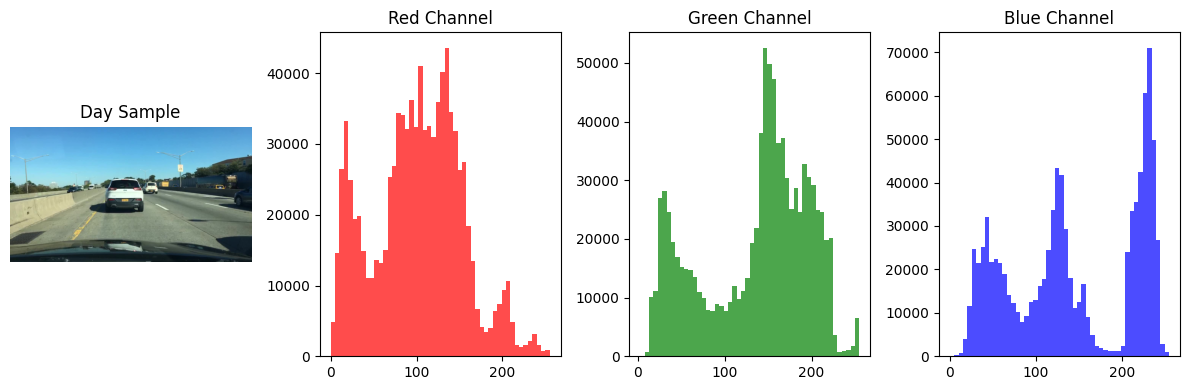

In [22]:
visualize_RGB(day_sample, "Day Sample")

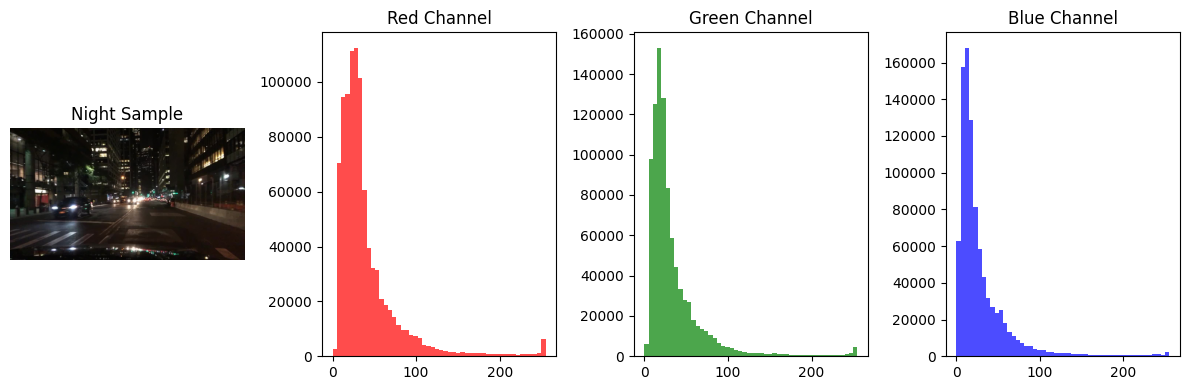

In [23]:
visualize_RGB(night_sample, "Night Sample")

## RGB Channel Mean Distribution

In [24]:
def get_rgb_means(directory):
    means = []
    for f in os.listdir(directory)[:100]:
        with Image.open(os.path.join(directory, f)) as img:
            arr = np.array(img)
            means.append(arr.mean(axis=(0,1)))
    return np.array(means)

day_rgb = get_rgb_means(day_dir)
night_rgb = get_rgb_means(night_dir)

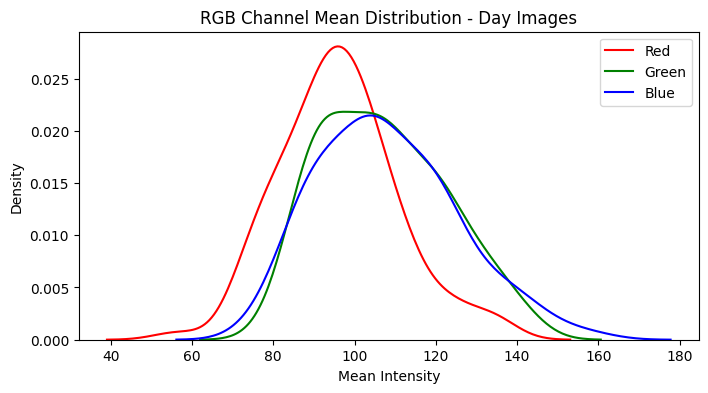

In [25]:
plt.figure(figsize=(8,4))
sns.kdeplot(day_rgb[:,0], label='Red', color='r')
sns.kdeplot(day_rgb[:,1], label='Green', color='g')
sns.kdeplot(day_rgb[:,2], label='Blue', color='b')
plt.title("RGB Channel Mean Distribution - Day Images")
plt.xlabel("Mean Intensity")
plt.ylabel("Density")
plt.legend()
plt.show()

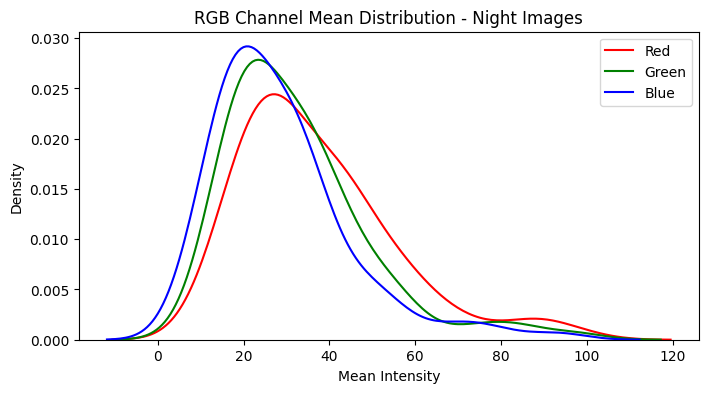

In [26]:
plt.figure(figsize=(8,4))
sns.kdeplot(night_rgb[:,0], label='Red', color='r')
sns.kdeplot(night_rgb[:,1], label='Green', color='g')
sns.kdeplot(night_rgb[:,2], label='Blue', color='b')
plt.title("RGB Channel Mean Distribution - Night Images")
plt.xlabel("Mean Intensity")
plt.ylabel("Density")
plt.legend()
plt.show()

## Brightness Distribution

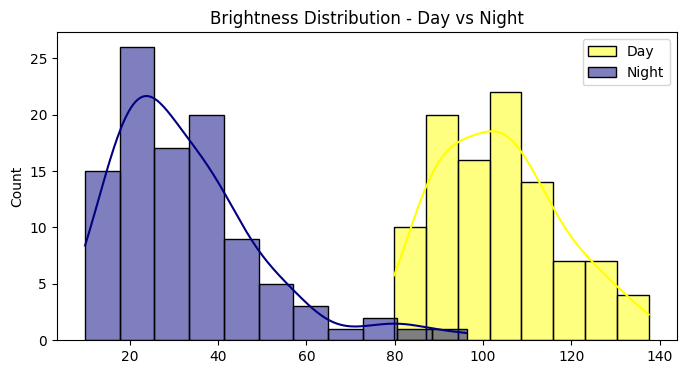

In [27]:
def brightness(img_array):
    return np.mean(img_array)

day_brightness = [
    brightness(np.array(Image.open(os.path.join(day_dir, f))))
    for f in day_files[:100]
]
night_brightness = [
    brightness(np.array(Image.open(os.path.join(night_dir, f))))
    for f in night_files[:100]
]

plt.figure(figsize=(8,4))
sns.histplot(day_brightness, color='yellow', label='Day', kde=True)
sns.histplot(night_brightness, color='navy', label='Night', kde=True)
plt.title("Brightness Distribution - Day vs Night")
plt.legend()
plt.show()

## Color Channel Correlation

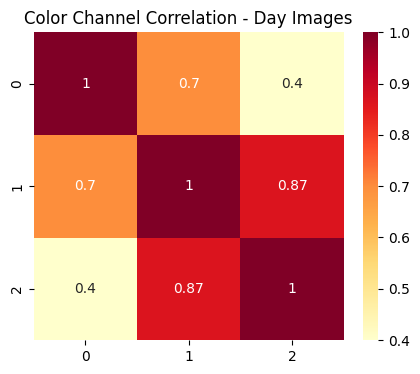

In [28]:
corr_day = np.corrcoef(day_rgb.T)
corr_night = np.corrcoef(night_rgb.T)

plt.figure(figsize=(5,4))
sns.heatmap(corr_day, annot=True, cmap='YlOrRd')
plt.title("Color Channel Correlation - Day Images")
plt.show()

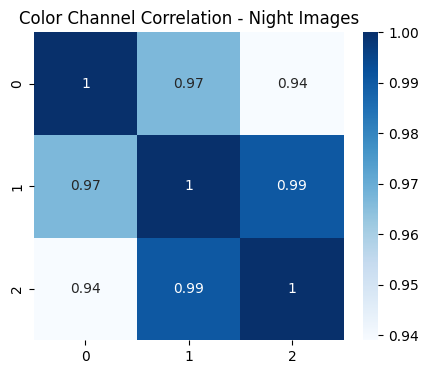

In [29]:
plt.figure(figsize=(5,4))
sns.heatmap(corr_night, annot=True, cmap='Blues')
plt.title("Color Channel Correlation - Night Images")
plt.show()